# **RIDGE regression – compound dependence**

Here we evaluated the near-optimal settings for the model in terms of the best performing <code>MAPE</code>. We have implemented sequential grid search for <code>Training Window</code> length and $\lambda$ regularization parameter.

We include heat-map visuals to better comprehend the behaviour observed.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Ridge

# In case of convergence problem, supress warning
import warnings

#warnings.filterwarnings("ignore")

In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **RIDGE regression**

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_trackerENPH = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:
    for window_length in range(2, 31):
        for ticker in ["ENPH"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerENPH[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 7.743055189190604
(0.0001, 3) 4.107429914767526
(0.0001, 4) 3.8946621937597232
(0.0001, 5) 3.8664501825373456
(0.0001, 6) 3.913071831984108
(0.0001, 7) 3.9998072297874456
(0.0001, 8) 4.0321575643867895
(0.0001, 9) 4.065425986875978
(0.0001, 10) 4.165785314010931
(0.0001, 11) 4.218167011417127
(0.0001, 12) 4.266155561337644
(0.0001, 13) 4.316912186343271
(0.0001, 14) 4.370745106620525
(0.0001, 15) 4.36659665941534
(0.0001, 16) 4.392233106191494
(0.0001, 17) 4.440143913990077
(0.0001, 18) 4.518198284511998
(0.0001, 19) 4.546055707880171
(0.0001, 20) 4.5923109818926395
(0.0001, 21) 4.656786057898501
(0.0001, 22) 4.741844259618457
(0.0001, 23) 4.842364938036459
(0.0001, 24) 4.92127146438873
(0.0001, 25) 4.953666101530859
(0.0001, 26) 4.9846536117698275
(0.0001, 27) 5.053039000372005
(0.0001, 28) 5.069098870690809
(0.0001, 29) 5.12598518770331
(0.0001, 30) 5.223914045984723
(0.01, 2) 7.742998827150422
(0.01, 3) 4.107416946036102
(0.01, 4) 3.8946508184867428
(0.01, 5) 3.866438183

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/4239538046.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

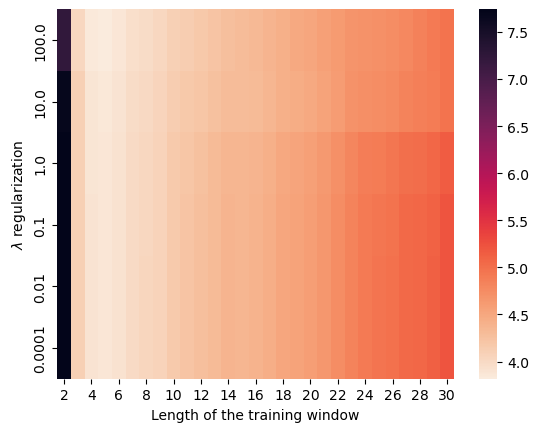

In [4]:
df = pd.Series(performance_trackerENPH).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [5]:
np.argmin(list(performance_trackerENPH.values()))

np.int64(148)

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_trackerROP = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["ROP"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerROP[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 2.6760799759941594
(0.0001, 3) 1.297054253500436
(0.0001, 4) 1.232982263269864
(0.0001, 5) 1.225772898147988
(0.0001, 6) 1.2288874383130817
(0.0001, 7) 1.2486365260575727
(0.0001, 8) 1.266701085104472
(0.0001, 9) 1.2772790478376412
(0.0001, 10) 1.3095207759126788
(0.0001, 11) 1.3218622187192608
(0.0001, 12) 1.333668881918088
(0.0001, 13) 1.3528427519233694
(0.0001, 14) 1.36568443645195
(0.0001, 15) 1.381519778394898
(0.0001, 16) 1.3906896812962741
(0.0001, 17) 1.4028185391868067
(0.0001, 18) 1.4189038969475374
(0.0001, 19) 1.423160180232943
(0.0001, 20) 1.441410085070469
(0.0001, 21) 1.4669746249779192
(0.0001, 22) 1.4716346789218713
(0.0001, 23) 1.4873431420662053
(0.0001, 24) 1.5042989332293852
(0.0001, 25) 1.51187225442514
(0.0001, 26) 1.5289032920807837
(0.0001, 27) 1.5315692486843466
(0.0001, 28) 1.5342815536435486
(0.0001, 29) 1.5380266240149612
(0.0001, 30) 1.5303870135588857
(0.01, 2) 2.6760593361933527
(0.01, 3) 1.297049745787413
(0.01, 4) 1.2329783528636837
(0.01,

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/508553450.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

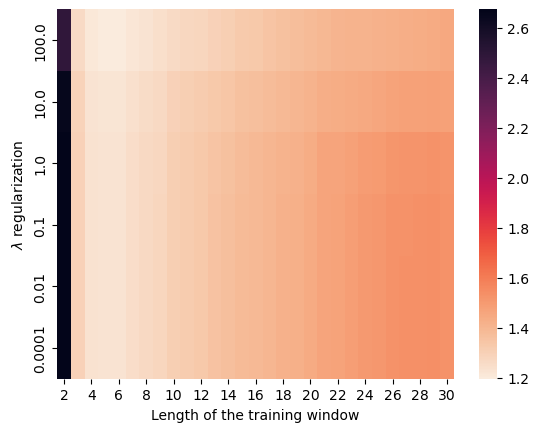

In [7]:
df = pd.Series(performance_trackerROP).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [8]:
np.argmin(list(performance_trackerROP.values()))

np.int64(149)

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_trackerSMCI = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["SMCI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerSMCI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 4.707373383119334
(0.0001, 3) 2.3911736832420707
(0.0001, 4) 2.288353278445444
(0.0001, 5) 2.297862936168311
(0.0001, 6) 2.3376915167048633
(0.0001, 7) 2.392079052328257
(0.0001, 8) 2.4363917736603202
(0.0001, 9) 2.477548959034451
(0.0001, 10) 2.5531610178101336
(0.0001, 11) 2.5752911317968237
(0.0001, 12) 2.5932347245784695
(0.0001, 13) 2.6232339844559083
(0.0001, 14) 2.648075249534314
(0.0001, 15) 2.665411400306214
(0.0001, 16) 2.6677411122027936
(0.0001, 17) 2.689420029167878
(0.0001, 18) 2.712130286111232
(0.0001, 19) 2.7553744630964836
(0.0001, 20) 2.7848483357306835
(0.0001, 21) 2.8323787382681513
(0.0001, 22) 2.887762929612949
(0.0001, 23) 2.8848671084230384
(0.0001, 24) 2.9050579422019243
(0.0001, 25) 2.898305378920361
(0.0001, 26) 2.9145294947316596
(0.0001, 27) 2.9669077813981586
(0.0001, 28) 2.99650961624283
(0.0001, 29) 3.014035683886976
(0.0001, 30) 3.02304062854438
(0.01, 2) 4.7073379632765375
(0.01, 3) 2.3911654958297683
(0.01, 4) 2.2883443603049156
(0.01, 5)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/2340393621.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

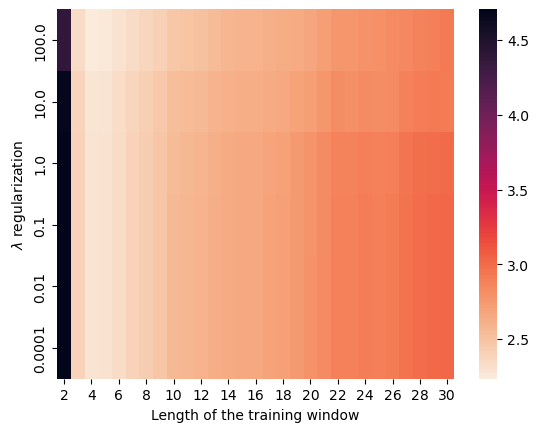

In [10]:
df = pd.Series(performance_trackerSMCI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [11]:
np.argmin(list(performance_trackerSMCI.values()))

np.int64(147)

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_trackerMSI = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["MSI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerMSI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 2.7543944166244216
(0.0001, 3) 1.4169953051261108
(0.0001, 4) 1.3499142386299368
(0.0001, 5) 1.3292158278259578
(0.0001, 6) 1.3262645591623956
(0.0001, 7) 1.3526022199546752
(0.0001, 8) 1.3729508095401035
(0.0001, 9) 1.3964181587726225
(0.0001, 10) 1.394962302517558
(0.0001, 11) 1.4223475224517539
(0.0001, 12) 1.426712617204403
(0.0001, 13) 1.4370550826161053
(0.0001, 14) 1.4483906785266285
(0.0001, 15) 1.442479382244928
(0.0001, 16) 1.4589083830510212
(0.0001, 17) 1.4763026363410703
(0.0001, 18) 1.4889062278096719
(0.0001, 19) 1.500283572959549
(0.0001, 20) 1.5187931032937048
(0.0001, 21) 1.5385700388221966
(0.0001, 22) 1.5577114299019612
(0.0001, 23) 1.5798732681301186
(0.0001, 24) 1.5911270461519949
(0.0001, 25) 1.6028010265088348
(0.0001, 26) 1.6213262282370222
(0.0001, 27) 1.6413292690022834
(0.0001, 28) 1.6508693093577576
(0.0001, 29) 1.6469978697119043
(0.0001, 30) 1.6476953405159116
(0.01, 2) 2.754373953912164
(0.01, 3) 1.416989633868101
(0.01, 4) 1.3499081893286582

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/2595922068.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

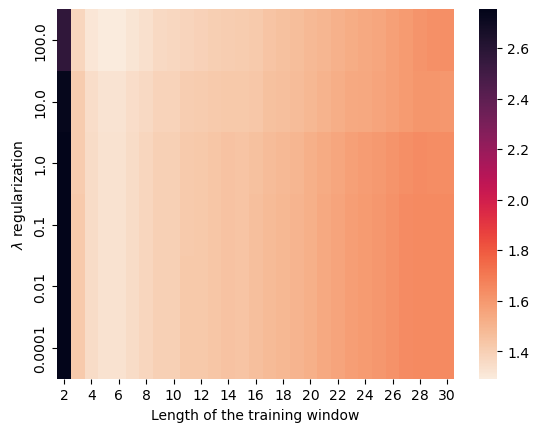

In [13]:
df = pd.Series(performance_trackerMSI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [ ]:
print(np.argmin(list(performance_trackerENPH.values())))
print(np.argmin(list(performance_trackerSMCI.values())))
print(np.argmin(list(performance_trackerROP.values())))
print(np.argmin(list(performance_trackerMSI.values())))

# In both cases we get argmin values
# 147 -> (100, 4)
# 148 -> (100, 5)
# We perform validation and compare average deviation for 
# both parameters

list(performance_trackerROP.keys())[148]

148
147
149
149


(100, 5)

# Analysis of certain $\lambda$

We perform in-depth analysis of regularization parameter for the fixed, experimentally derived near-optimal training window length.

In [15]:
performance_trackerENPH_regularization = {}

for Alpha in range(10, 1000, 10):#np.logspace(-4, 2, 50):
    for ticker in ["SMCI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerENPH_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


10 2.279948380091203 450
20 2.272197112302301 450
30 2.265112588010144 450
40 2.2586172717208832 450
50 2.252760934688066 450
60 2.2474989286879734 450
70 2.24291470289334 450
80 2.2389025123278463 450
90 2.2360937850141718 450
100 2.2337322559221424 450
110 2.231825261698532 450
120 2.230421986861792 450
130 2.2292639777811907 450
140 2.228312952856923 450
150 2.22756383283938 450
160 2.227106171488364 450
170 2.2269228829835686 450
180 2.226997467116192 450
190 2.227137964069464 450
200 2.227412015366152 450
210 2.2278157950171664 450
220 2.2282952218454732 450
230 2.2288947371621157 450
240 2.229577794646155 450
250 2.2303332345048417 450
260 2.231253635334149 450
270 2.2322649261054495 450
280 2.233524970356132 450
290 2.234935961825043 450
300 2.236439230090158 450
310 2.238064677410265 450
320 2.2397115469565443 450
330 2.2413724122178005 450
340 2.2431474402129536 450
350 2.245031060627507 450
360 2.2471332372467687 450
370 2.249253560010753 450
380 2.25144744877761 450
390 2.25

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/3755794406.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


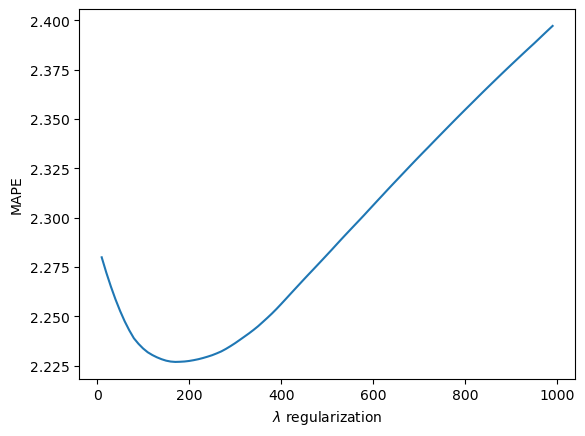

In [16]:
plt.plot(performance_trackerENPH_regularization.keys(), performance_trackerENPH_regularization.values())

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

plt.show()

In [17]:
performance_trackerROP_regularization = {}

for Alpha in range(10, 1000, 10):#np.logspace(-4, 2, 50):
    for ticker in ["ROP"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerROP_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


10 1.229197961181124 450
20 1.2258120025818857 450
30 1.222728519943864 450
40 1.2199973800933057 450
50 1.2176543642917728 450
60 1.2156102122036145 450
70 1.2137734512320069 450
80 1.2121549266352134 450
90 1.21068642591915 450
100 1.2094000080621639 450
110 1.2082211821899154 450
120 1.2071159400312714 450
130 1.2061137968274485 450
140 1.2052622250866107 450
150 1.2045382942240377 450
160 1.2039442388248727 450
170 1.2034289045471864 450
180 1.2029967554651693 450
190 1.2026472962926327 450
200 1.2023956968869614 450
210 1.2022122629209717 450
220 1.2020970288722657 450
230 1.2020431738689032 450
240 1.2020666312587296 450
250 1.2021578103309618 450
260 1.2023198992914197 450
270 1.2025293692431507 450
280 1.2027734395195915 450
290 1.2030783627965302 450
300 1.2034006875908638 450
310 1.20373323120786 450
320 1.2041499027526579 450
330 1.2046253359968173 450
340 1.2051085050415595 450
350 1.2056002400457009 450
360 1.2061156559975095 450
370 1.2066595418541468 450
380 1.2072342173

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/1799825415.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


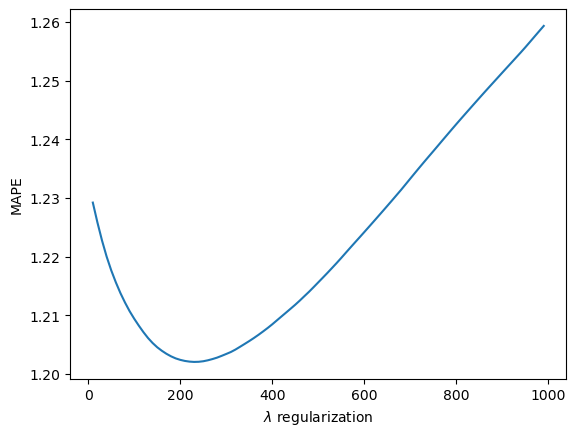

In [18]:
plt.plot(performance_trackerROP_regularization.keys(), performance_trackerROP_regularization.values())

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

plt.show()

In [19]:
performance_trackerMSI_regularization = {}

for Alpha in range(10, 1000, 10):#np.logspace(-4, 2, 50):
    for ticker in ["MSI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerMSI_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


10 1.3441042199939757 450
20 1.3388234947720141 450
30 1.3340472809898698 450
40 1.329726825190847 450
50 1.3257686685272372 450
60 1.3221785107232866 450
70 1.3190205793882397 450
80 1.3161164092451434 450
90 1.3135630429849299 450
100 1.3112516502496319 450
110 1.3092287893705832 450
120 1.307377764879916 450
130 1.305720897816573 450
140 1.3042175921186545 450
150 1.3028915361309845 450
160 1.3017594007649633 450
170 1.3008676763895959 450
180 1.300076615898412 450
190 1.2993297474426635 450
200 1.2986275747355347 450
210 1.2980187670710115 450
220 1.2974559300738167 450
230 1.2969553776537222 450
240 1.2966918102967264 450
250 1.2965732518782846 450
260 1.296494172623151 450
270 1.2964843468703708 450
280 1.296498290490742 450
290 1.2965570843399086 450
300 1.2966263830830906 450
310 1.296704434253734 450
320 1.2967876274220291 450
330 1.2968797522152333 450
340 1.297008692594335 450
350 1.297176030008315 450
360 1.2973540830018426 450
370 1.2975360525366304 450
380 1.2977259456791

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/1589099792.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


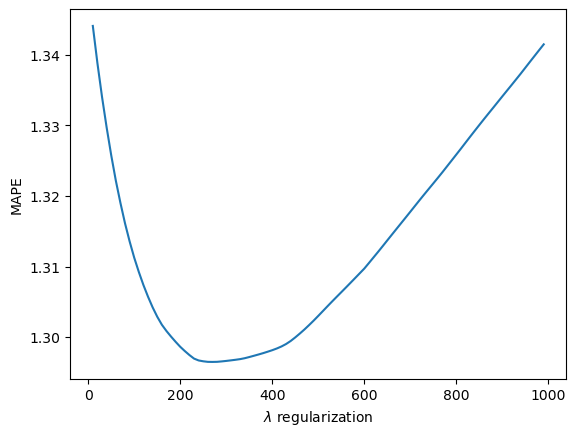

In [20]:
plt.plot(performance_trackerMSI_regularization.keys(), performance_trackerMSI_regularization.values())

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

plt.show()

In [21]:
# argmins: 120, 210, 230
# MAPES: 1.7646582872746024, 1.7618944509177021, 1.7627612508756563 
# Dominances: 0.4485343399714957, 0.4447517429991141, 0.444066099148723

In [22]:
performance_trackerMSI_regularization = {}

for Alpha in range(200, 250):
    for ticker in ["MSI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerMSI_regularization[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


200 1.2986275747355347 450
201 1.2985614337850815 450
202 1.298499993891625 450
203 1.2984388442422512 450
204 1.2983779829509017 450
205 1.2983174081473068 450
206 1.298257117976823 450
207 1.2981971106002694 450
208 1.2981373841937702 450
209 1.2980779369485966 450
210 1.2980187670710115 450
211 1.2979598727821156 450
212 1.2979012523176943 450
213 1.297842903928071 450
214 1.2977848258779563 450
215 1.2977282608481882 450
216 1.2976732813484628 450
217 1.2976185601627277 450
218 1.2975640956426937 450
219 1.2975098861535475 450
220 1.2974559300738167 450
221 1.2974022257952345 450
222 1.2973487717226073 450
223 1.2972955662736838 450
224 1.2972426078790262 450
225 1.29718989498188 450
226 1.2971388283708816 450
227 1.2970924135972082 450
228 1.2970462579149966 450
229 1.2970003232512537 450
230 1.2969553776537222 450
231 1.2969131944100243 450
232 1.2968806892985727 450
233 1.29685347377308 450
234 1.296826974898529 450
235 1.2968028590612726 450
236 1.2967789036191848 450
237 1.296

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_24204/3908297301.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ regularization")


Text(0, 0.5, 'MAPE')

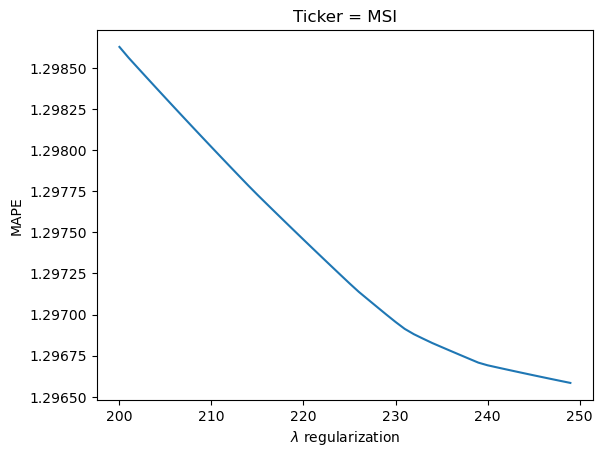

In [23]:
plt.plot(performance_trackerMSI_regularization.keys(), performance_trackerMSI_regularization.values())

plt.title("Ticker = MSI")

plt.xlabel("$\lambda$ regularization")
plt.ylabel("MAPE")

In [24]:
performance_trackerENPH_regularization_detail = {}

for Alpha in range(150, 250):
    for ticker in ["ENPH"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Ridge(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerENPH_regularization_detail[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs), np.sum(MODEL.coef_ != 0))


150 3.8281254370208457 450
151 3.828070789591859 450
152 3.8280279160115485 450
153 3.8279885334547274 450
154 3.8279497998123744 450
155 3.8279117094255892 450
156 3.8278742566915764 450
157 3.827837436062983 450
158 3.82780124204724 450
159 3.827766849139083 450
160 3.8277338536547654 450
161 3.8277014626597934 450
162 3.827669670922886 450
163 3.8276399159977736 450
164 3.82761130299021 450
165 3.8275832672540537 450
166 3.827555803792045 450
167 3.8275289076554246 450
168 3.8275025739433723 450
169 3.8274767978024493 450
170 3.827452988109844 450
171 3.8274388242257125 450
172 3.827431575382003 450
173 3.82743595339372 450
174 3.827454812319908 450
175 3.8274780075601385 450
176 3.8275060615328482 450
177 3.827539316571422 450
178 3.8275760587734653 450
179 3.8276131477095636 450
180 3.827652125879151 450
181 3.8276916589131704 450
182 3.82773152294348 450
183 3.8277739642754547 450
184 3.8278181879343354 450
185 3.8278627217377186 450
186 3.827907562387692 450
187 3.82795270661929

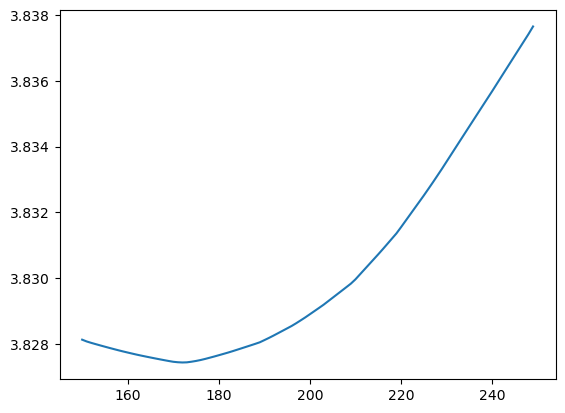

In [25]:
plt.plot(performance_trackerENPH_regularization_detail.keys(), performance_trackerENPH_regularization_detail.values())